# 01 - Data Exploration

## Nuclei Segmentation in Histopathology Images

This notebook explores the MoNuSeg and TNBC datasets used in our POC.

**What we'll cover:**
- Loading and visualizing H&E stained images
- Understanding ground truth masks
- Image statistics (size, intensity distributions)
- Dataset characteristics comparison

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.measure import label, regionprops

from src.utils.data_loader import load_dataset, load_all_datasets
from src.utils.visualization import show_image_and_mask, show_pipeline_steps

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Path to data directory (adjust if needed)
DATA_ROOT = '../../data'

print('Setup complete!')

Setup complete!


## 1. Load Both Datasets

In [2]:
datasets = load_all_datasets(DATA_ROOT)

for name, data in datasets.items():
    print(f"\nDataset: {name.upper()}")
    print(f"  Number of images: {len(data['images'])}")
    print(f"  Image shape: {data['images'][0].shape}")
    print(f"  Mask shape: {data['masks'][0].shape}")
    print(f"  Image dtype: {data['images'][0].dtype}")
    print(f"  Mask unique values: {np.unique(data['masks'][0])}")

Loaded monuseg: 8 images, resolution 256x256
Loaded monuseg_full: 37 images, resolution 1000x1000
Loaded tnbc: 50 images, resolution 256x256

Dataset: MONUSEG
  Number of images: 8
  Image shape: (256, 256, 3)
  Mask shape: (256, 256)
  Image dtype: uint8
  Mask unique values: [0 1]

Dataset: MONUSEG_FULL
  Number of images: 37
  Image shape: (1000, 1000, 3)
  Mask shape: (1000, 1000)
  Image dtype: uint8
  Mask unique values: [0 1]

Dataset: TNBC
  Number of images: 50
  Image shape: (256, 256, 3)
  Mask shape: (256, 256)
  Image dtype: uint8
  Mask unique values: [0 1]


## 2. Visualize Sample Images

H&E (Hematoxylin and Eosin) staining is the most common staining method:
- **Hematoxylin** stains nuclei **blue/purple**
- **Eosin** stains cytoplasm and extracellular matrix **pink**

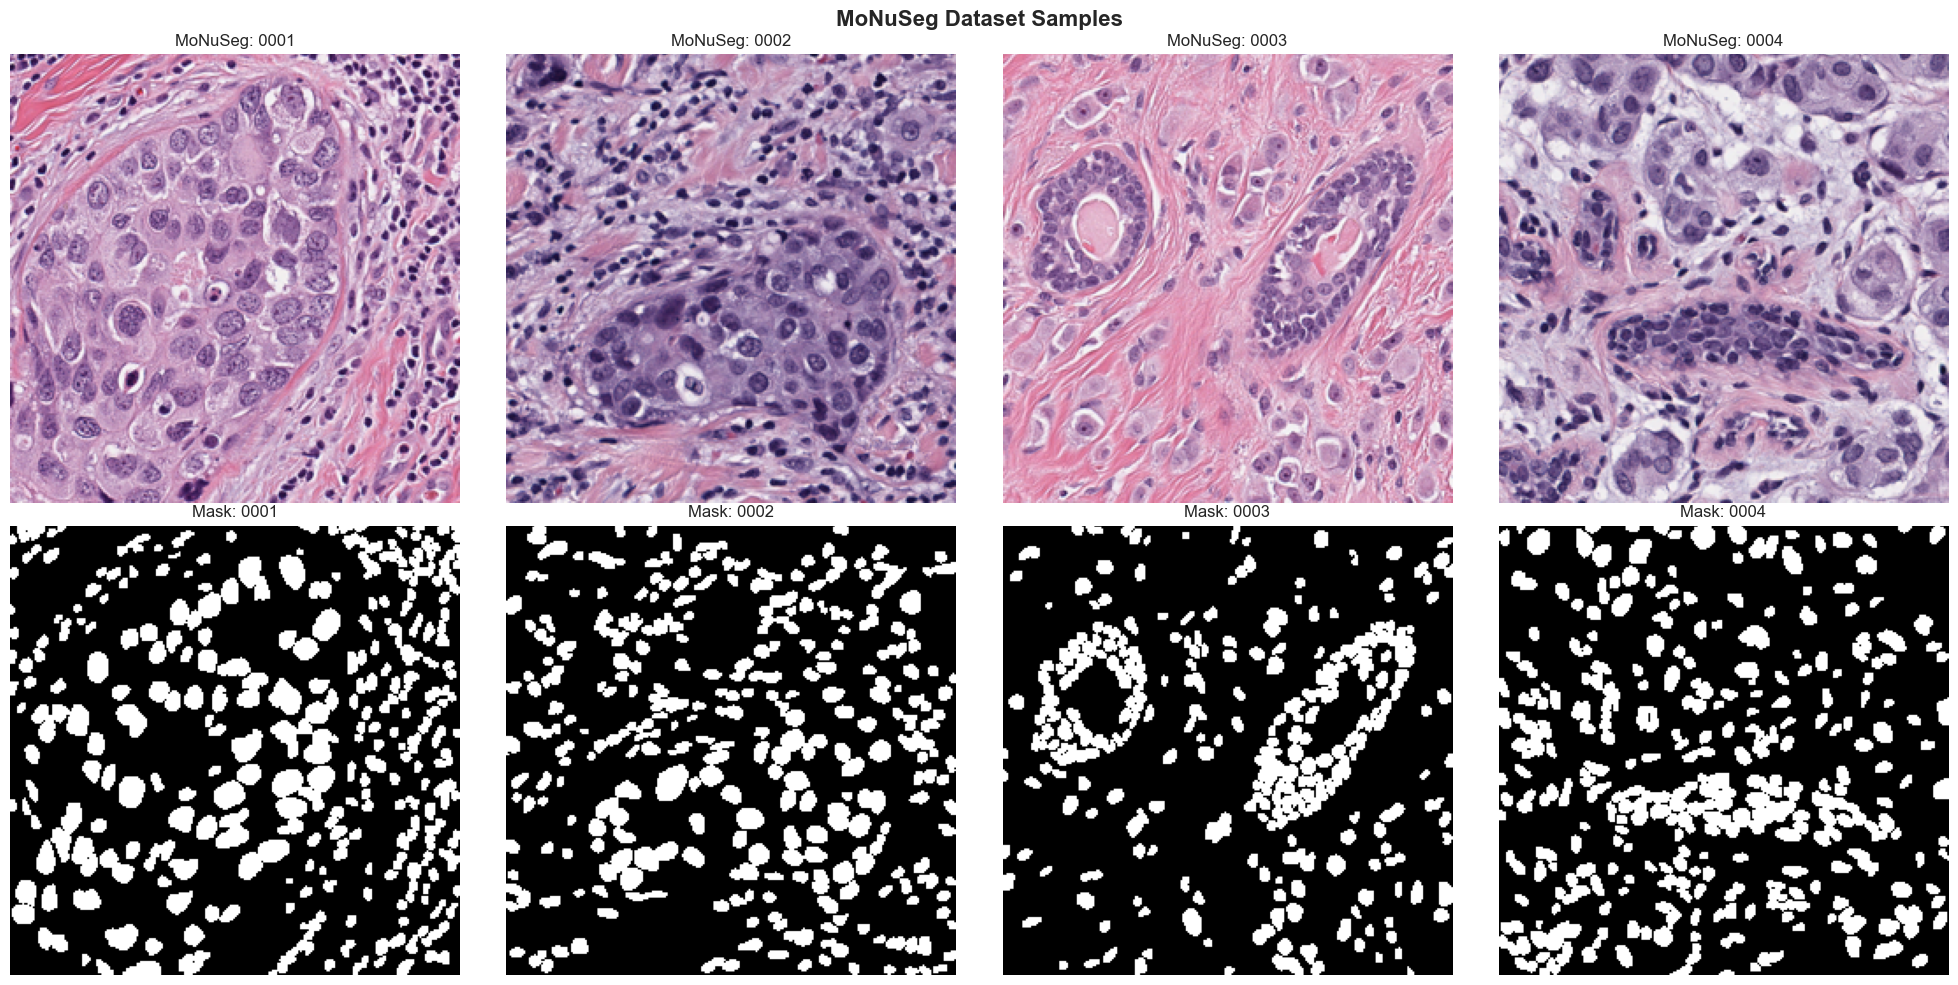

In [3]:
# Show samples from MoNuSeg
if 'monuseg' in datasets:
    monuseg = datasets['monuseg']
    n_show = min(4, len(monuseg['images']))
    
    fig, axes = plt.subplots(2, n_show, figsize=(5*n_show, 10))
    for i in range(n_show):
        axes[0, i].imshow(monuseg['images'][i])
        axes[0, i].set_title(f"MoNuSeg: {monuseg['names'][i]}")
        axes[0, i].axis('off')
        
        axes[1, i].imshow(monuseg['masks'][i], cmap='gray')
        axes[1, i].set_title(f"Mask: {monuseg['names'][i]}")
        axes[1, i].axis('off')
    
    plt.suptitle('MoNuSeg Dataset Samples', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

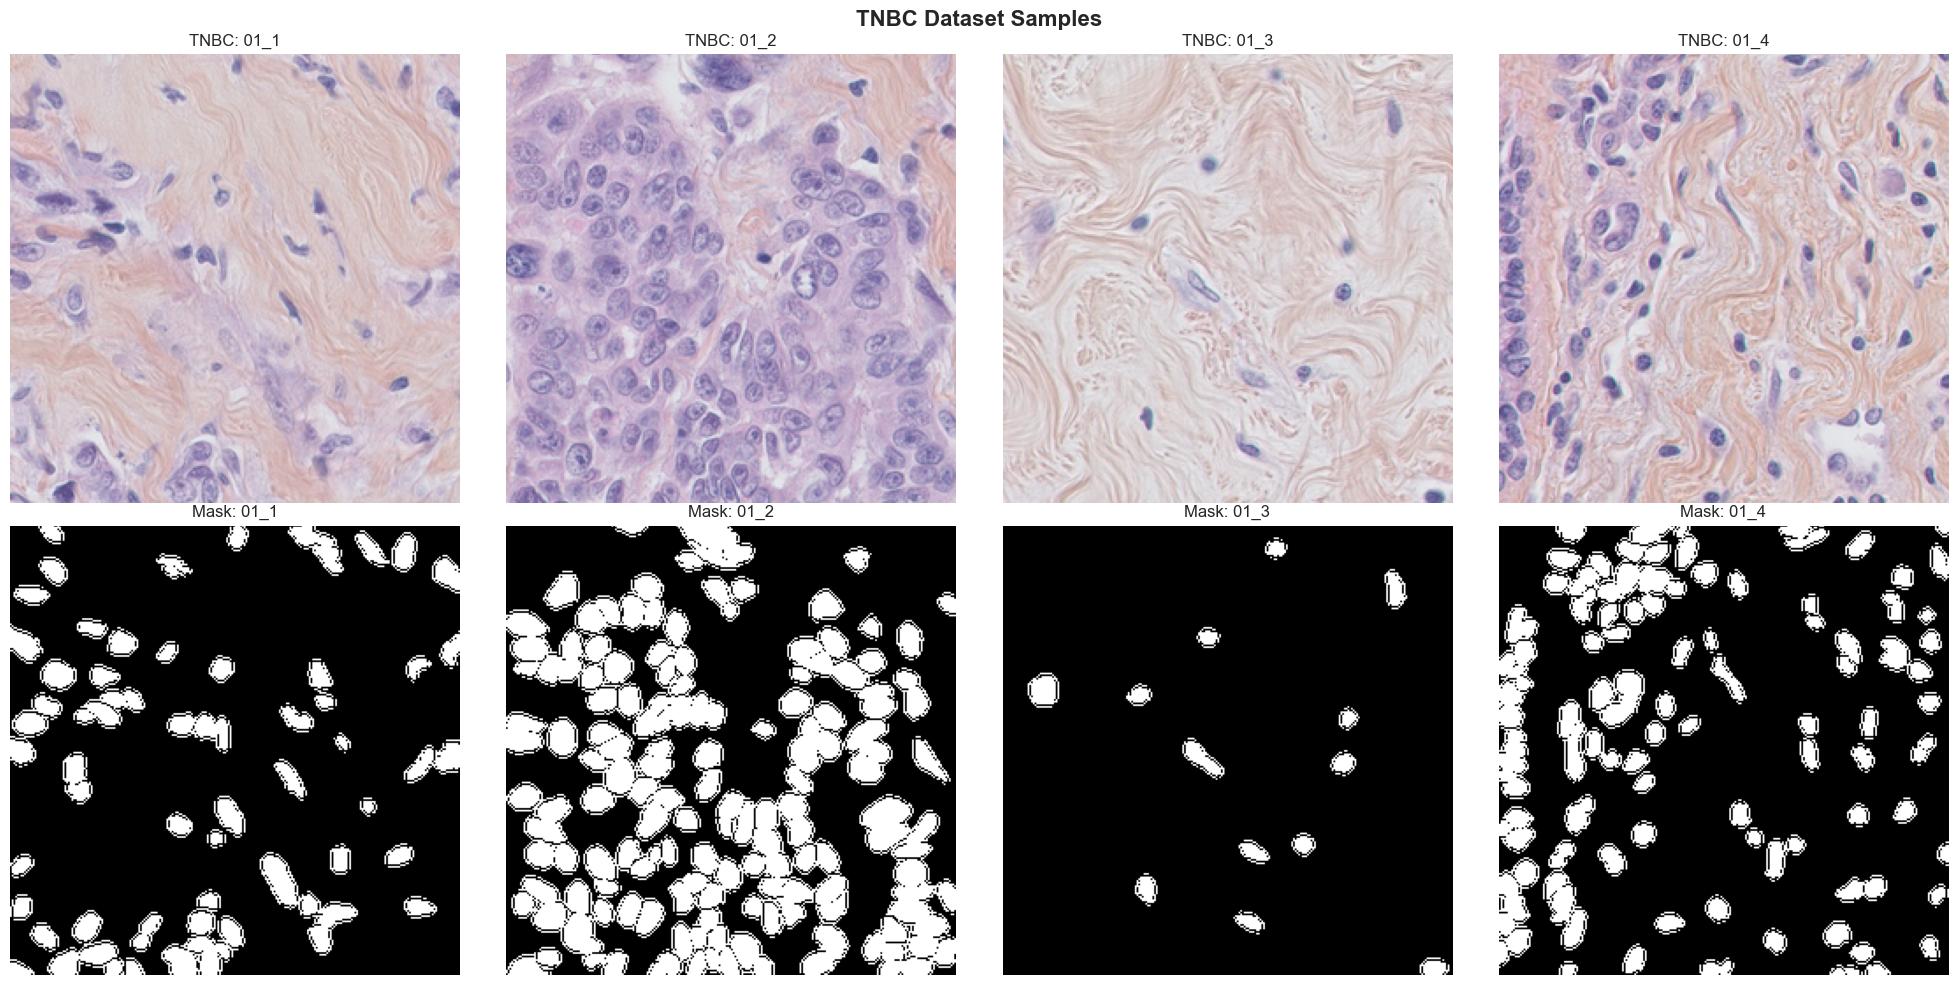

In [4]:
# Show samples from TNBC
if 'tnbc' in datasets:
    tnbc = datasets['tnbc']
    n_show = min(4, len(tnbc['images']))
    
    fig, axes = plt.subplots(2, n_show, figsize=(5*n_show, 10))
    for i in range(n_show):
        axes[0, i].imshow(tnbc['images'][i])
        axes[0, i].set_title(f"TNBC: {tnbc['names'][i]}")
        axes[0, i].axis('off')
        
        axes[1, i].imshow(tnbc['masks'][i], cmap='gray')
        axes[1, i].set_title(f"Mask: {tnbc['names'][i]}")
        axes[1, i].axis('off')
    
    plt.suptitle('TNBC Dataset Samples', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 3. Image Statistics

Let's analyze the color distributions and nuclei characteristics.

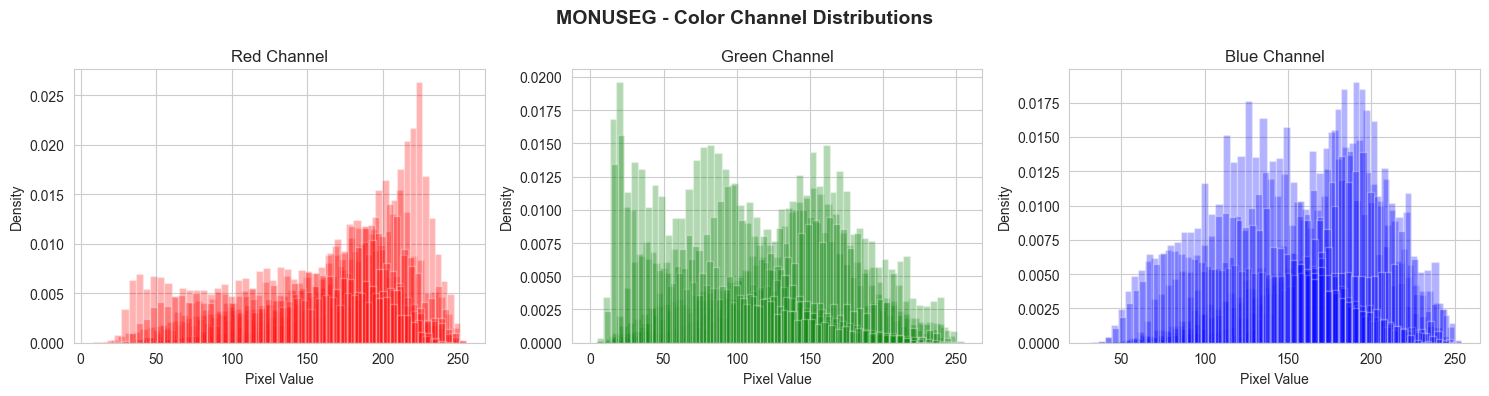

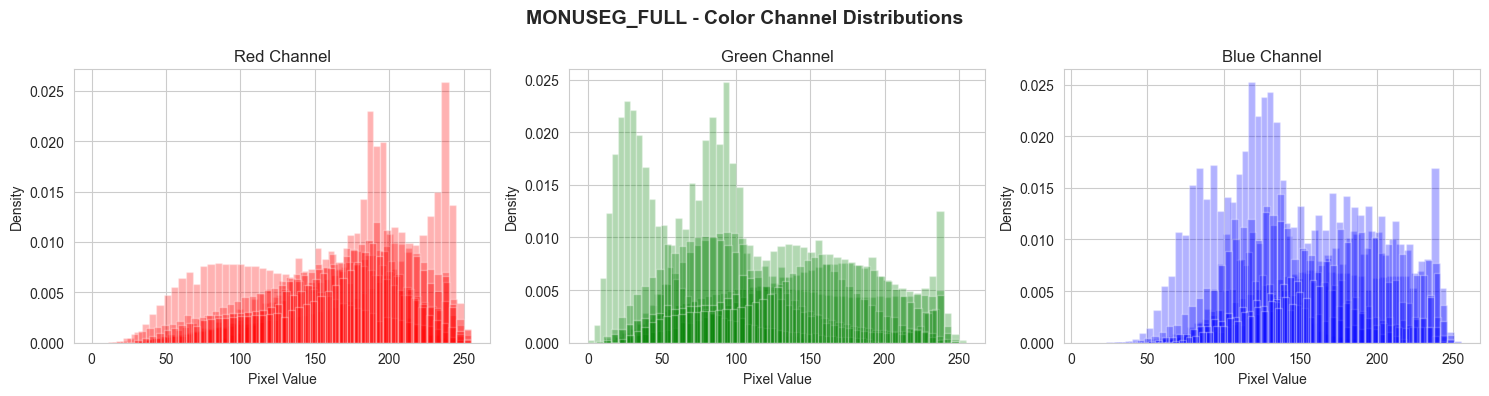

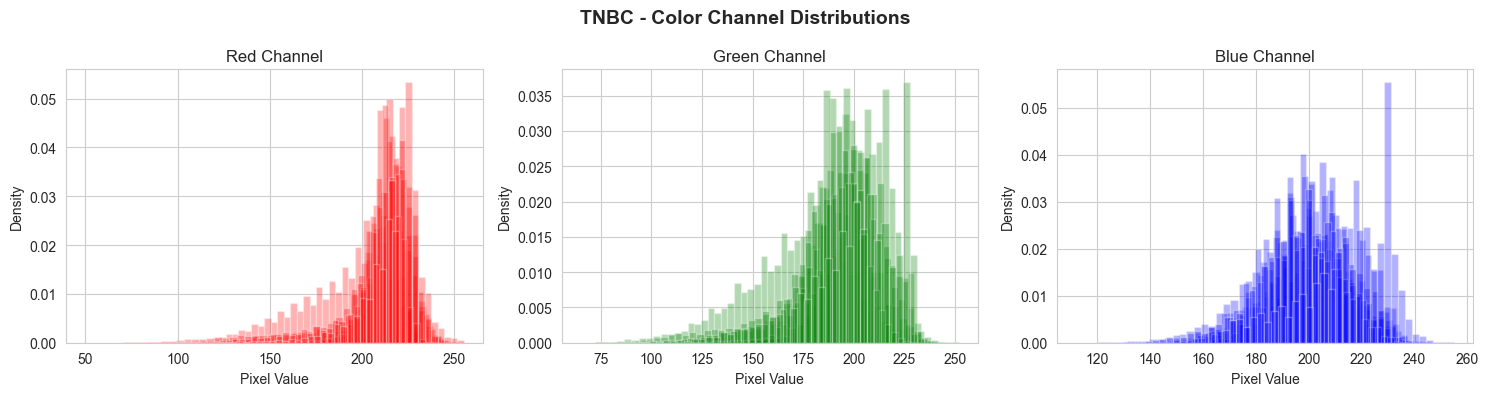

In [6]:
# Color channel distributions
for ds_name, data in datasets.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    channel_names = ['Red', 'Green', 'Blue']
    colors = ['red', 'green', 'blue']
    
    for ch in range(3):
        for i, img in enumerate(data['images'][:8]):
            axes[ch].hist(img[:,:,ch].ravel(), bins=50, alpha=0.3, 
                         color=colors[ch], density=True)
        axes[ch].set_title(f'{channel_names[ch]} Channel')
        axes[ch].set_xlabel('Pixel Value')
        axes[ch].set_ylabel('Density')
    
    plt.suptitle(f'{ds_name.upper()} - Color Channel Distributions', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [7]:
# Nuclei statistics per image
import pandas as pd

all_stats = []
for ds_name, data in datasets.items():
    for i, (mask, name) in enumerate(zip(data['masks'], data['names'])):
        labeled = label(mask)
        props = regionprops(labeled)
        areas = [p.area for p in props]
        
        stats = {
            'Dataset': ds_name.upper(),
            'Image': name,
            'Num Nuclei': len(props),
            'Mean Area': np.mean(areas) if areas else 0,
            'Std Area': np.std(areas) if areas else 0,
            'Nuclei Density (%)': 100 * np.sum(mask > 0) / mask.size,
            'Image Width': data['images'][i].shape[1],
            'Image Height': data['images'][i].shape[0],
        }
        all_stats.append(stats)

df_stats = pd.DataFrame(all_stats)
print("\nPer-Image Statistics:")
print(df_stats.to_string(index=False))


Per-Image Statistics:
     Dataset                   Image  Num Nuclei   Mean Area    Std Area  Nuclei Density (%)  Image Width  Image Height
     MONUSEG                    0001         175  107.674286  118.879685           28.752136          256           256
     MONUSEG                    0002         184   89.407609   88.575515           25.102234          256           256
     MONUSEG                    0003         132   94.583333  271.579389           19.050598          256           256
     MONUSEG                    0004         176   96.346591  192.384083           25.874329          256           256
     MONUSEG                    0005         156  134.564103  183.866388           32.031250          256           256
     MONUSEG                    0006          99  266.141414  517.695906           40.203857          256           256
     MONUSEG                    0007         162  139.098765  171.970505           34.384155          256           256
     MONUSEG     

In [8]:
# Summary statistics by dataset
print("\nSummary by Dataset:")
summary = df_stats.groupby('Dataset')[['Num Nuclei', 'Mean Area', 'Nuclei Density (%)']].agg(
    ['mean', 'std', 'min', 'max']
)
print(summary.round(2))


Summary by Dataset:
             Num Nuclei                    Mean Area                           \
                   mean     std  min   max      mean     std     min      max   
Dataset                                                                         
MONUSEG          153.75   27.94   99   184    138.31   59.75   89.41   266.14   
MONUSEG_FULL     471.46  275.78  158  1026    703.01  398.81  144.07  1849.34   
TNBC              66.36   32.32    4   122    188.90  100.04   58.11   519.13   

             Nuclei Density (%)                       
                           mean    std    min    max  
Dataset                                               
MONUSEG                   30.65   7.39  19.05  40.20  
MONUSEG_FULL              26.74   9.82  11.91  42.67  
TNBC                      20.04  13.78   0.69  47.87  


IndexError: index 2 is out of bounds for axis 0 with size 2

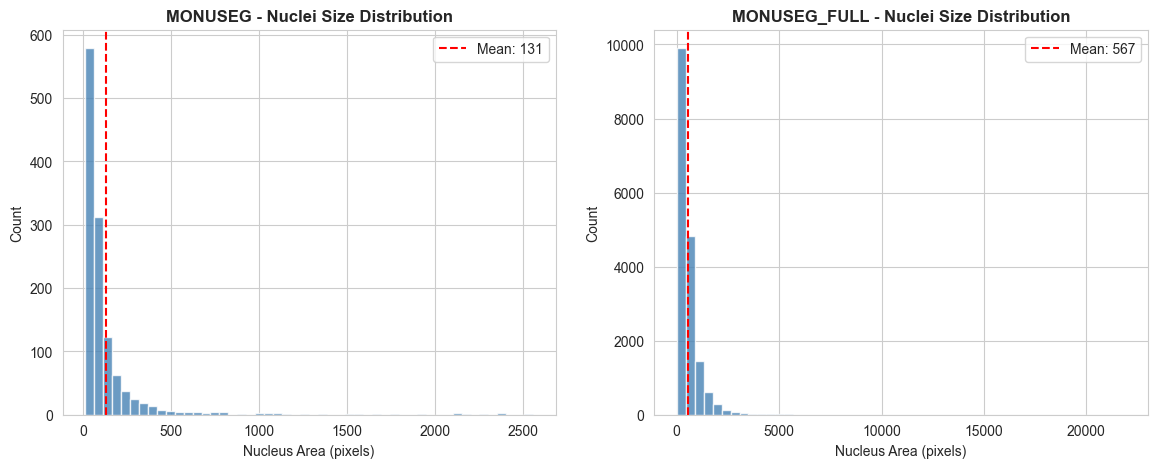

In [9]:
# Visualize nuclei size distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (ds_name, data) in enumerate(datasets.items()):
    all_areas = []
    for mask in data['masks']:
        labeled = label(mask)
        props = regionprops(labeled)
        all_areas.extend([p.area for p in props])
    
    axes[idx].hist(all_areas, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[idx].set_title(f'{ds_name.upper()} - Nuclei Size Distribution', fontweight='bold')
    axes[idx].set_xlabel('Nucleus Area (pixels)')
    axes[idx].set_ylabel('Count')
    axes[idx].axvline(np.mean(all_areas), color='red', linestyle='--', 
                      label=f'Mean: {np.mean(all_areas):.0f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("\nKey Takeaway: Nuclei vary significantly in size, especially in cancer tissue.")
print("This makes fixed thresholding approaches unreliable - motivating adaptive methods.")

## 4. Staining Variation Challenge

One of the key challenges highlighted in the paper is **staining variation**:
- Different labs use different H&E stain concentrations
- Scanner models produce different color profiles
- Even within a single slide, staining can be inconsistent

This is why **stain normalization** is crucial for automated analysis.

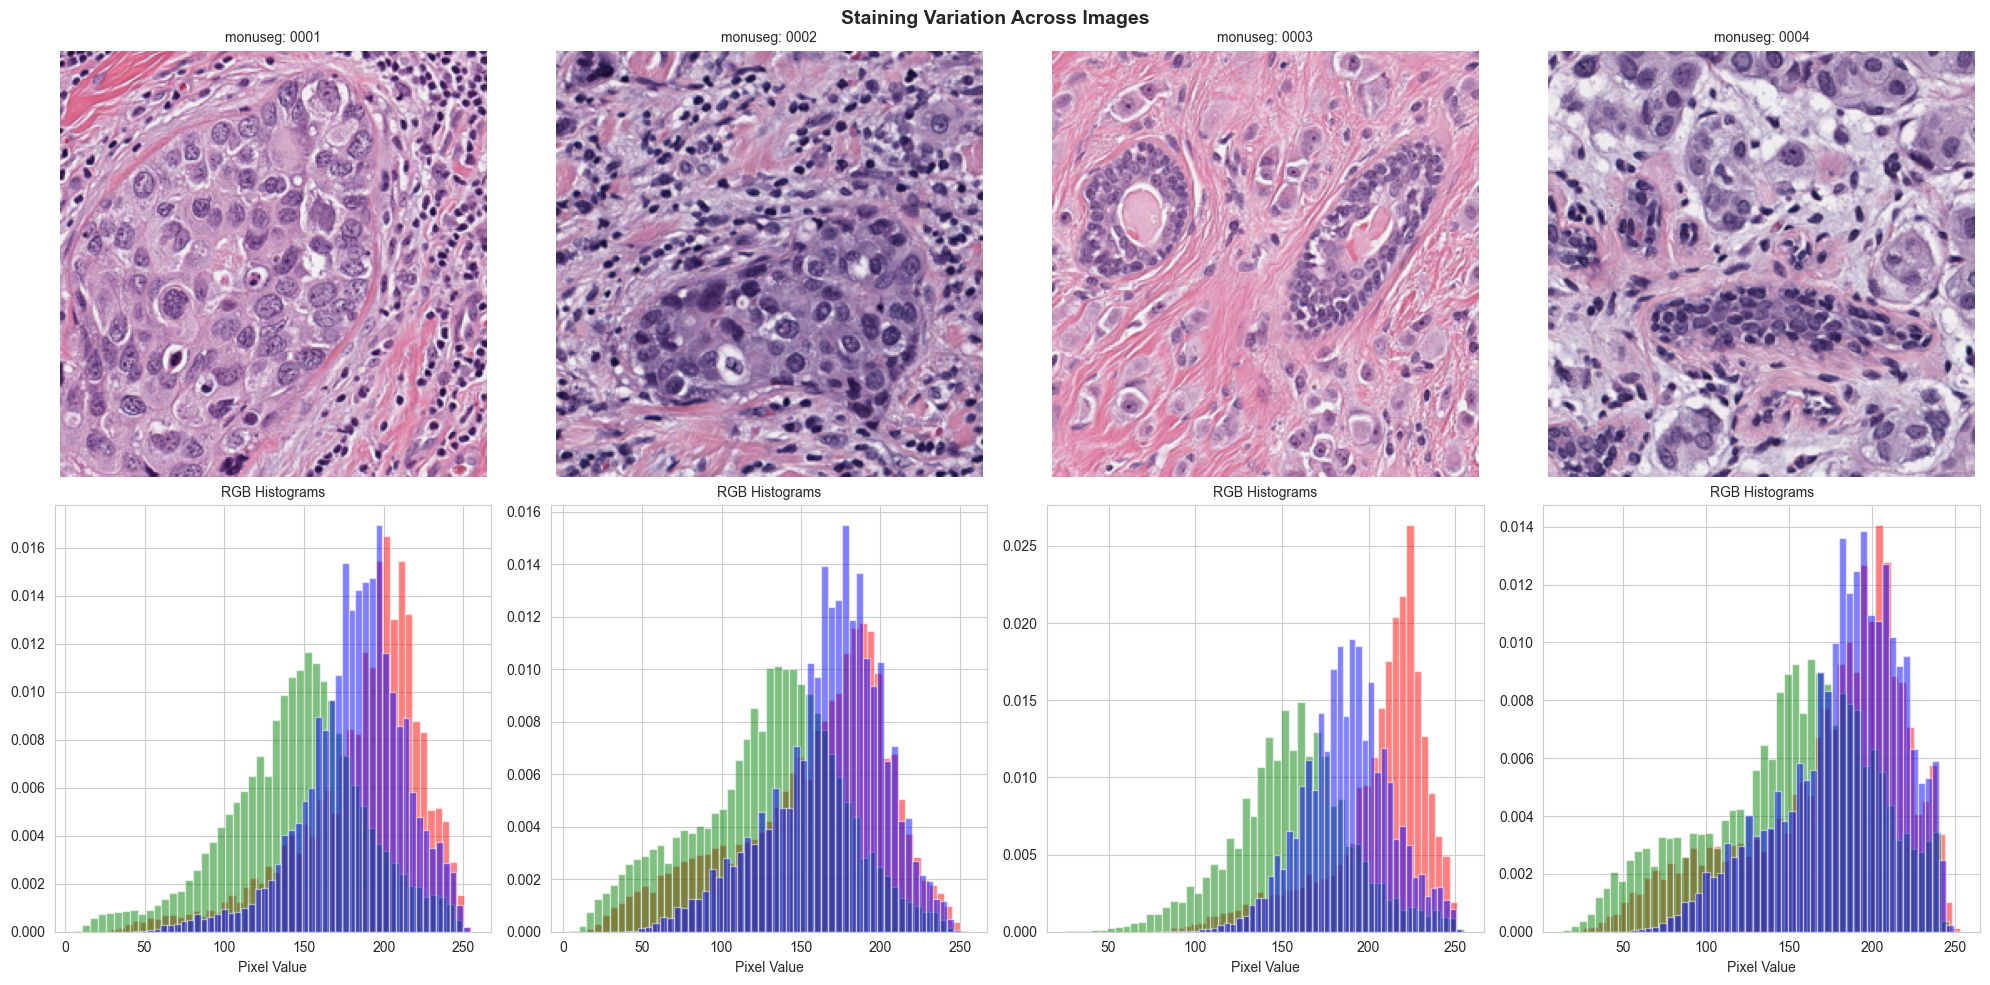


Notice how colors vary between images - this is the staining variation problem.
Stain normalization aims to make all images look like they came from the same lab.


In [10]:
# Show staining variation across images
all_images = []
all_labels = []
for ds_name, data in datasets.items():
    for i, (img, name) in enumerate(zip(data['images'][:4], data['names'][:4])):
        all_images.append(img)
        all_labels.append(f"{ds_name}: {name}")

n = len(all_images)
fig, axes = plt.subplots(2, min(n, 4), figsize=(5*min(n, 4), 10))

for i in range(min(n, 4)):
    axes[0, i].imshow(all_images[i])
    axes[0, i].set_title(all_labels[i], fontsize=10)
    axes[0, i].axis('off')
    
    # Show mean color patch
    mean_color = all_images[i].mean(axis=(0,1)).astype(np.uint8)
    color_patch = np.full((50, 50, 3), mean_color, dtype=np.uint8)
    
    # Histogram of all channels
    for ch, color in enumerate(['red', 'green', 'blue']):
        axes[1, i].hist(all_images[i][:,:,ch].ravel(), bins=50, 
                       alpha=0.5, color=color, density=True)
    axes[1, i].set_title(f'RGB Histograms', fontsize=10)
    axes[1, i].set_xlabel('Pixel Value')

plt.suptitle('Staining Variation Across Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNotice how colors vary between images - this is the staining variation problem.")
print("Stain normalization aims to make all images look like they came from the same lab.")